In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from glob import glob
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [2]:
# =========================
# Creating dataframe to store songs, song_path and label
# =========================

DATA_DIR = "Final Project Data/genres_original"
file_paths = glob(os.path.join(DATA_DIR, "*", "*.wav"))

rows =[]
for path in file_paths:
    if(path != "Final Project Data/genres_original/jazz/jazz.00054.wav"):
        genre = path[path.rfind("/") + 1 : path.find(".")]
        song_id = path[path.rfind("/") + 1 :].replace(".wav", "")
        rows.append({"path": path, "genre": genre, "song_id": song_id})
df = pd.DataFrame(rows).sort_values(["genre", "song_id"]).reset_index(drop=True)
df


,path,genre,song_id
0,Final Project Data/genres_original/blues/blues...,blues,blues.00000
1,Final Project Data/genres_original/blues/blues...,blues,blues.00001
2,Final Project Data/genres_original/blues/blues...,blues,blues.00002
3,Final Project Data/genres_original/blues/blues...,blues,blues.00003
4,Final Project Data/genres_original/blues/blues...,blues,blues.00004
...,...,...,...
994,Final Project Data/genres_original/rock/rock.0...,rock,rock.00095
995,Final Project Data/genres_original/rock/rock.0...,rock,rock.00096
996,Final Project Data/genres_original/rock/rock.0...,rock,rock.00097
997,Final Project Data/genres_original/rock/rock.0...,rock,rock.00098


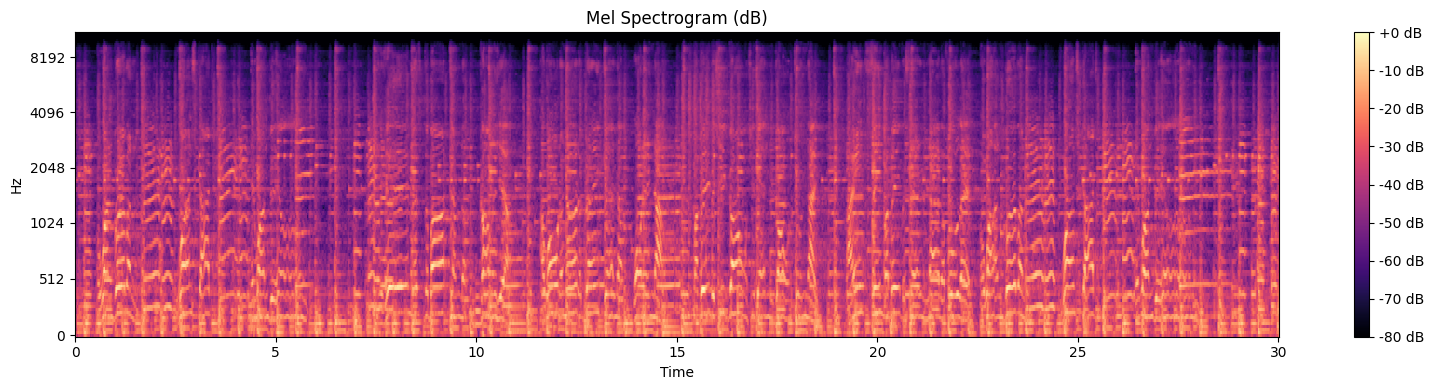

In [3]:
# =========================
# Mel Spectrogram Demonstration
# =========================

path = df.loc[0, "path"]
y, sr = librosa.load(path, sr=22050, mono=True)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(16,4))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram (dB)")
plt.tight_layout()
plt.show()

In [4]:
# =========================
# Function for extracting mel-features from inputted song
# =========================

def extract_features(y, sr):
    # zero-crossing rate -> frequency at which a signal changes sign within a specific timeframe
        # transitions / segment length
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

    # spectral centroid -> center of mass or weighted average frequency of the sound spectrum
        # where most of sound energy is concentrated 
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    # spectral roll-off -> frequency below which a specific percentage (typically 85-95%) of a signal's total spectral energy resides
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    # mfccs -> small set of features describing overall shape of spectral envelope
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # chroma frequencies -> small set of features describing overall shape of spectral envelope
    chroma_frequencies = librosa.feature.chroma_stft(y=y, sr=sr)

    features = []
    for feature in [zero_crossing_rate, spectral_centroid, spectral_rolloff, mfcc ,chroma_frequencies]:
        features.append(np.mean(feature, axis=1))
        features.append(np.std(feature, axis=1))
    return np.concatenate(features)


In [5]:
# =========================
# Preprocessing & Train-Test Split
# =========================

le = LabelEncoder()
y = le.fit_transform(df["genre"].values)

X = []
for path in df["path"].values:
    y_audio, sr = librosa.load(path, sr=22050, mono=True)
    feats = extract_features(y_audio, sr)  # (72,)
    X.append(feats)
X = np.vstack(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# =========================
# Defining Models to Evaluate on the Dataset
# =========================

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, n_jobs=-1, l1_ratio=0.5),
    "Perceptron": Perceptron(max_iter=2000, tol=1e-3, random_state=42),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "SVM (RBF_SVC)": SVC(random_state=42, kernel='rbf', gamma=0.02),
    "Naive Bayes (GaussianNB)": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, max_depth=12),
    "Random Forest Tuned": RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, max_depth=6),
    "MLP" : MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-2,           
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        random_state=42
    ),
    "Decision Tree Tuned": DecisionTreeClassifier(
        random_state=42,
        max_depth=10,       
        min_samples_leaf=1,       
        min_samples_split=2,      
        ccp_alpha=0.01,
        criterion='entropy'
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=10,
        weights="distance",
        p=1,
        leaf_size=10,
        algorithm="auto",
        metric="minkowski"
    )
}

In [7]:
# =========================
# Train & Evaluate Models Independently
# =========================

def weighted_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return acc, prec, rec, f1

results = []
best = {"name": None, "pipe": None, "test_f1": -1.0}
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("scale", StandardScaler()),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    yhat_tr = pipe.predict(X_train)
    yhat_te = pipe.predict(X_test)

    tr = weighted_metrics(y_train, yhat_tr)
    te = weighted_metrics(y_test, yhat_te)

    results.append([name, *tr, *te])

    if te[3] > best["test_f1"]:
        best["name"] = name
        best["pipe"] = pipe
        best["test_f1"] = te[3]

cols = ["Model",
        "Train Acc", "Train Prec(w)", "Train Rec(w)", "Train F1(w)",
        "Test Acc",  "Test Prec(w)",  "Test Rec(w)",  "Test F1(w)"]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1(w)", ascending=False)

print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec(w)": "{:.4f}".format,
    "Train Rec(w)": "{:.4f}".format,
    "Train F1(w)": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec(w)": "{:.4f}".format,
    "Test Rec(w)": "{:.4f}".format,
    "Test F1(w)": "{:.4f}".format,
}))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


                   Model Train Acc Train Prec(w) Train Rec(w) Train F1(w) Test Acc Test Prec(w) Test Rec(w) Test F1(w)
     Logistic Regression    0.9086        0.9083       0.9086      0.9084   0.7100       0.7068      0.7100     0.7031
         SVM (LinearSVC)    0.8811        0.8814       0.8811      0.8803   0.7000       0.6989      0.7000     0.6937
           SVM (RBF_SVC)    0.9412        0.9421       0.9412      0.9413   0.6850       0.6893      0.6850     0.6804
                     MLP    0.9024        0.9033       0.9024      0.9025   0.6800       0.6826      0.6800     0.6752
           Random Forest    0.9987        0.9988       0.9987      0.9987   0.6700       0.6718      0.6700     0.6665
                     KNN    0.9987        0.9988       0.9987      0.9987   0.6600       0.6813      0.6600     0.6533
     Random Forest Tuned    0.9524        0.9529       0.9524      0.9523   0.6300       0.6223      0.6300     0.6174
              Perceptron    0.7284        0.7274


Best model by Test weighted F1: Logistic Regression  (Test F1(w)=0.7031)
--------------------------------------------------------------------------------

[TEST] Classification Report:
              precision    recall  f1-score   support

           0     0.7222    0.6500    0.6842        20
           1     1.0000    0.9500    0.9744        20
           2     0.6087    0.7000    0.6512        20
           3     0.4444    0.4000    0.4211        20
           4     0.6364    0.7000    0.6667        20
           5     0.7826    0.9000    0.8372        20
           6     0.8571    0.9000    0.8780        20
           7     0.7500    0.9000    0.8182        20
           8     0.6000    0.6000    0.6000        20
           9     0.6667    0.4000    0.5000        20

    accuracy                         0.7100       200
   macro avg     0.7068    0.7100    0.7031       200
weighted avg     0.7068    0.7100    0.7031       200



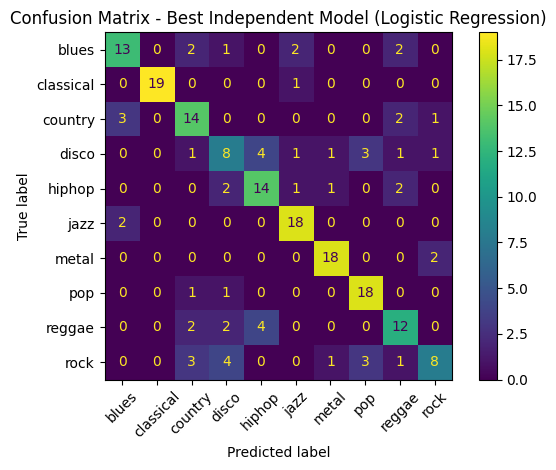

In [8]:
# =========================
# Classification Report & CM for best performing model: LogisticRegression
# =========================

print("\n" + "=" * 80)
print(f"Best model by Test weighted F1: {best['name']}  (Test F1(w)={best['test_f1']:.4f})")
print("-" * 80)

yhat_best = best["pipe"].predict(X_test)

print("\n[TEST] Classification Report:")
print(classification_report(y_test, yhat_best, digits=4, zero_division=0))

cm = confusion_matrix(y_test, yhat_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_   # shows genre names instead of 0,1,2,...
)
disp.plot(values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best Independent Model ({best['name']})")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# Pipelines for StackingClassifiers
# =========================

lr_pipe = Pipeline(steps=[
    ("prep", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, n_jobs=-1, l1_ratio=0.5))
])
rf_pipe = Pipeline(steps=[
    ("prep", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, max_depth=6)),
])
knn_pipe = Pipeline(steps=[
    ("prep", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=10, leaf_size=10, metric="euclidean")),
])
svm_pipe = Pipeline(steps=[
    ("prep", StandardScaler()),
    ("model", SVC(C=3.0, kernel="rbf", probability=True, random_state=42)),
])
gnb_pipe = Pipeline(steps=[
    ("prep", StandardScaler()),  
    ("model", GaussianNB()),
])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skle

Training Classification Report
              precision    recall  f1-score   support

           0     0.9630    0.9750    0.9689        80
           1     1.0000    1.0000    1.0000        80
           2     0.9375    0.9375    0.9375        80
           3     0.8523    0.9375    0.8929        80
           4     0.9024    0.9250    0.9136        80
           5     0.9873    0.9873    0.9873        79
           6     0.9625    0.9625    0.9625        80
           7     0.9615    0.9375    0.9494        80
           8     0.9054    0.8375    0.8701        80
           9     0.8701    0.8375    0.8535        80

    accuracy                         0.9337       799
   macro avg     0.9342    0.9337    0.9336       799
weighted avg     0.9341    0.9337    0.9335       799

Testing Classification Report
              precision    recall  f1-score   support

           0     0.7368    0.7000    0.7179        20
           1     1.0000    1.0000    1.0000        20
           2     

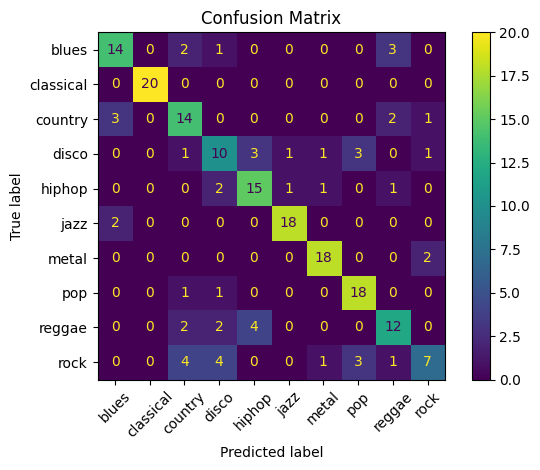

In [10]:
# =========================
# Train & Evaluate First Stack
# =========================

stack_1 = StackingClassifier(
    estimators=[("Logistic Regression", lr_pipe), ("RandomForest", rf_pipe)],
    final_estimator=LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs"),
    cv=5,
    n_jobs=1,
)

stack_1.fit(X_train, y_train)

yhat_tr = stack_1.predict(X_train)
yhat_te = stack_1.predict(X_test)

print("Training Classification Report")
print(classification_report(y_train, yhat_tr, digits=4, zero_division=0))

print("Testing Classification Report")
print(classification_report(y_test, yhat_te, digits=4, zero_division=0))

cm = confusion_matrix(y_test, yhat_te)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_   # shows genre names instead of 0,1,2,...
)
disp.plot(values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skle

Training Classification Report
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        80
           1     1.0000    1.0000    1.0000        80
           2     0.9753    0.9875    0.9814        80
           3     0.9390    0.9625    0.9506        80
           4     0.9630    0.9750    0.9689        80
           5     1.0000    1.0000    1.0000        79
           6     0.9506    0.9625    0.9565        80
           7     0.9870    0.9500    0.9682        80
           8     0.9740    0.9375    0.9554        80
           9     0.9012    0.9125    0.9068        80

    accuracy                         0.9687       799
   macro avg     0.9690    0.9688    0.9688       799
weighted avg     0.9690    0.9687    0.9687       799

Testing Classification Report
              precision    recall  f1-score   support

           0     0.6818    0.7500    0.7143        20
           1     0.9500    0.9500    0.9500        20
           2     

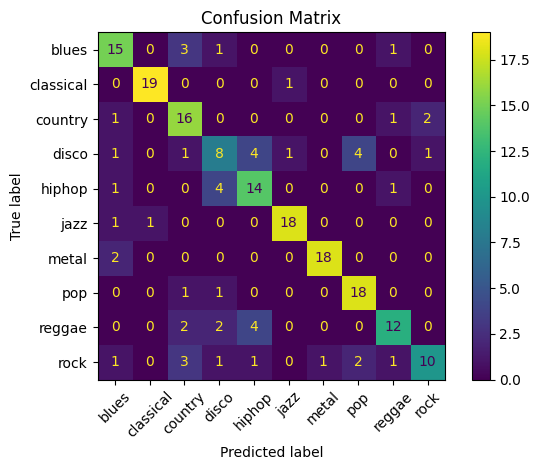

In [11]:
# =========================
# Train & Evaluate Second Stack
# =========================

stack_2 = StackingClassifier(
    estimators=[("Logistic Regression", lr_pipe), ("RandomForest", rf_pipe), ("KNN", knn_pipe), ("SVM", svm_pipe)],
    final_estimator=LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs"),
    cv=5,
    n_jobs=1,
)

stack_2.fit(X_train, y_train)

yhat_tr = stack_2.predict(X_train)
yhat_te = stack_2.predict(X_test)

print("Training Classification Report")
print(classification_report(y_train, yhat_tr, digits=4, zero_division=0))

print("Testing Classification Report")
print(classification_report(y_test, yhat_te, digits=4, zero_division=0))

cm = confusion_matrix(y_test, yhat_te)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_   # shows genre names instead of 0,1,2,...
)
disp.plot(values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skle

Training Classification Report
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        80
           1     1.0000    1.0000    1.0000        80
           2     0.9875    0.9875    0.9875        80
           3     0.9375    0.9375    0.9375        80
           4     0.9630    0.9750    0.9689        80
           5     1.0000    1.0000    1.0000        79
           6     0.9512    0.9750    0.9630        80
           7     0.9620    0.9500    0.9560        80
           8     0.9620    0.9500    0.9560        80
           9     0.9241    0.9125    0.9182        80

    accuracy                         0.9687       799
   macro avg     0.9687    0.9687    0.9687       799
weighted avg     0.9687    0.9687    0.9687       799

Testing Classification Report
              precision    recall  f1-score   support

           0     0.7727    0.8500    0.8095        20
           1     1.0000    0.9000    0.9474        20
           2     

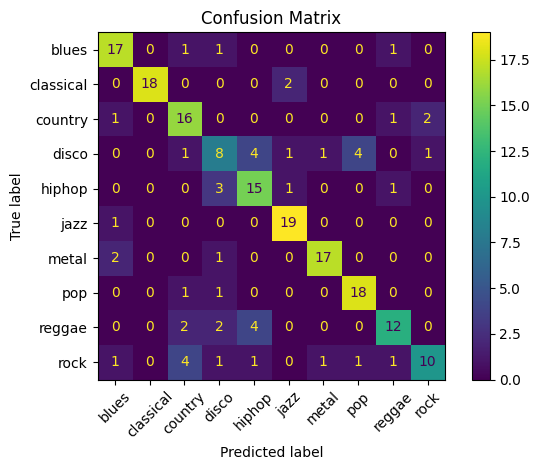

In [12]:
# =========================
# Train & Evaluate Third Stack
# =========================

stack_3 = StackingClassifier(
    estimators=[("Logistic Regression", lr_pipe), ("RandomForest", rf_pipe), ("KNN", knn_pipe), ("SVM", svm_pipe), ("GNB", gnb_pipe)],
    final_estimator=LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs"),
    cv=5,
    n_jobs=1,
)

stack_3.fit(X_train, y_train)

yhat_tr = stack_3.predict(X_train)
yhat_te = stack_3.predict(X_test)

print("Training Classification Report")
print(classification_report(y_train, yhat_tr, digits=4, zero_division=0))

print("Testing Classification Report")
print(classification_report(y_test, yhat_te, digits=4, zero_division=0))

cm = confusion_matrix(y_test, yhat_te)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_   # shows genre names instead of 0,1,2,...
)
disp.plot(values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()